In [7]:
import pandas as pd

In [8]:
df = pd.read_csv("Mall_Customers.csv")

In [9]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [10]:
df['high_value'] = df['Spending Score (1-100)'].apply(lambda x: 1 if x >= 60 else 0)

In [11]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
y = df['high_value']

In [13]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [23]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors = 5, metric = 'manhattan')
knn.fit(X_train,y_train)

KNeighborsClassifier(metric='manhattan')

In [17]:
y_pred = knn.predict(X_test)

In [18]:
from sklearn.metrics import accuracy_score
print(f"Accuracy Score: {accuracy_score(y_test,y_pred)}")

Accuracy Score: 0.9833333333333333


In [19]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),high_value
0,1,Male,19,15,39,0
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,0


In [20]:
new_cust = pd.DataFrame ({
    "Annual Income (k$)" : [25,30],
    "Spending Score (1-100)" : [54,80]
})

knn.predict(new_cust)

C:\ProgramData\Anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


array([1, 1], dtype=int64)

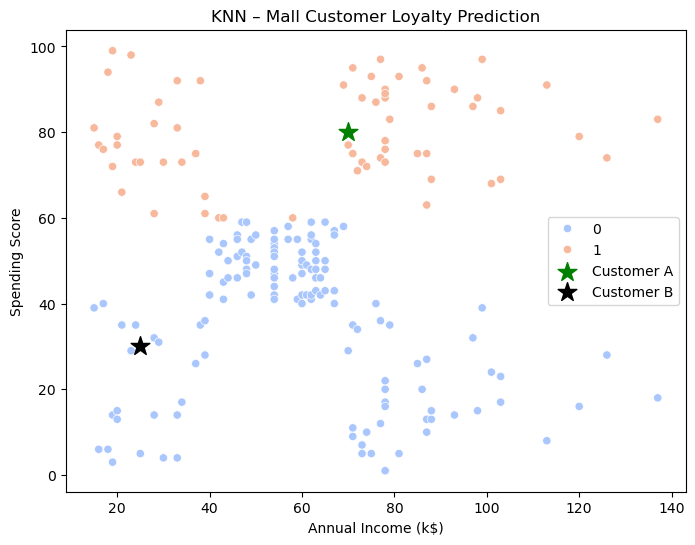

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df['Annual Income (k$)'],
    y=df['Spending Score (1-100)'],
    hue=df['high_value'],
    palette='coolwarm'
)

plt.scatter(70, 80, color='green', s=200, marker='*', label='Customer A')
plt.scatter(25, 30, color='black', s=200, marker='*', label='Customer B')

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("KNN – Mall Customer Loyalty Prediction")
plt.legend()
plt.show()
